In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
X = np.array([
    [1.0, 1.0],
    [1.5, 2.0],
    [2.0, 1.0],
    [1.0, 2.0],

    [5.0, 5.0],
    [6.0, 5.0],
    [5.5, 6.0],
    [6.0, 6.0],

    [8.0, 1.0],
    [9.0, 2.0],
    [9.0, 1.0],
    [8.0, 2.0]
])

print("Dataset shape:", X.shape)
print(X)

Dataset shape: (12, 2)
[[1.  1. ]
 [1.5 2. ]
 [2.  1. ]
 [1.  2. ]
 [5.  5. ]
 [6.  5. ]
 [5.5 6. ]
 [6.  6. ]
 [8.  1. ]
 [9.  2. ]
 [9.  1. ]
 [8.  2. ]]


#### Dataset Visualization

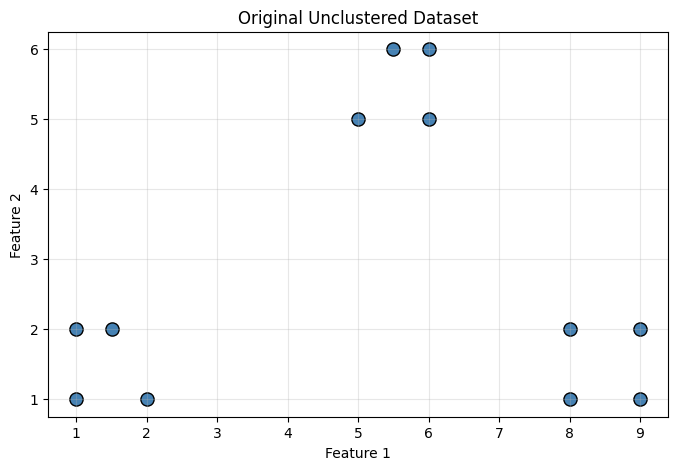

In [7]:
plt.figure(figsize=(8, 5))
plt.scatter(
    X[:, 0],
    X[:, 1],
    color="steelblue",
    s=90,
    edgecolor="black"
)

plt.title("Original Unclustered Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(alpha=0.3)
plt.show()

In [8]:
class KMeansFromScratch:
    def __init__(
        self,
        n_clusters=3,
        max_iter=100,
        tolerance=1e-4,
        random_state=None
    ):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tolerance = tolerance
        self.random_state = random_state

        self.centroids_ = None
        self.labels_ = None
        self.inertia_ = None
        self.n_iter_ = 0
        self.centroid_history_ = []

    def _initialize_centroids(self, X):
        random_generator = np.random.default_rng(
            self.random_state
        )

        selected_indices = random_generator.choice(
            len(X),
            size=self.n_clusters,
            replace=False
        )

        return X[selected_indices].copy()

    def _assign_clusters(self, X, centroids):
        differences = (
            X[:, np.newaxis, :]
            - centroids[np.newaxis, :, :]
        )

        squared_distances = np.sum(
            differences ** 2,
            axis=2
        )

        return np.argmin(
            squared_distances,
            axis=1
        )

    def _update_centroids(
        self,
        X,
        labels,
        previous_centroids
    ):
        new_centroids = np.zeros_like(
            previous_centroids
        )

        for cluster_id in range(self.n_clusters):
            cluster_points = X[
                labels == cluster_id
            ]

            if len(cluster_points) > 0:
                new_centroids[cluster_id] = (
                    cluster_points.mean(axis=0)
                )
            else:
                distances = np.sum(
                    (
                        X[:, np.newaxis, :]
                        - previous_centroids[
                            np.newaxis, :, :
                        ]
                    ) ** 2,
                    axis=2
                )

                minimum_distances = np.min(
                    distances,
                    axis=1
                )

                farthest_point_index = np.argmax(
                    minimum_distances
                )

                new_centroids[cluster_id] = X[
                    farthest_point_index
                ]

        return new_centroids

    def fit(self, X, initial_centroids=None):
        X = np.asarray(X, dtype=float)

        if X.ndim != 2:
            raise ValueError(
                "X must be a two-dimensional array."
            )

        if self.n_clusters <= 0:
            raise ValueError(
                "n_clusters must be greater than zero."
            )

        if self.n_clusters > len(X):
            raise ValueError(
                "n_clusters cannot exceed sample count."
            )

        if initial_centroids is None:
            centroids = self._initialize_centroids(X)
        else:
            centroids = np.asarray(
                initial_centroids,
                dtype=float
            )

            expected_shape = (
                self.n_clusters,
                X.shape[1]
            )

            if centroids.shape != expected_shape:
                raise ValueError(
                    f"Initial centroid shape must be "
                    f"{expected_shape}."
                )

            centroids = centroids.copy()
        self.centroid_history_ = [centroids.copy()]

        for iteration in range(self.max_iter):
            labels = self._assign_clusters(
                X,
                centroids
            )

            new_centroids = self._update_centroids(
                X,
                labels,
                centroids
            )

            centroid_shift = np.linalg.norm(new_centroids - centroids)
            centroids = new_centroids
            self.centroid_history_.append(centroids.copy())

            if centroid_shift <= self.tolerance:
                break

        self.centroids_ = centroids
        self.labels_ = self._assign_clusters(X,self.centroids_)
        squared_errors = (X - self.centroids_[self.labels_]) ** 2

        self.inertia_ = float(np.sum(squared_errors))
        self.n_iter_ = iteration + 1
        return self

    def predict(self, X):
        if self.centroids_ is None:
            raise RuntimeError(
                "The model must be fitted first."
            )

        X = np.asarray(X, dtype=float)
        return self._assign_clusters(
            X,
            self.centroids_
        )

    def fit_predict(
        self,
        X,
        initial_centroids=None
    ):
        self.fit(
            X,
            initial_centroids=initial_centroids
        )

        return self.labels_

#### Model Training

In [9]:
initial_centroids = np.array([
    [1.0, 1.0],
    [5.0, 5.0],
    [8.0, 1.0]
])

kmeans = KMeansFromScratch(
    n_clusters=3,
    max_iter=100,
    tolerance=1e-4,
    random_state=42
)

labels = kmeans.fit_predict(
    X,
    initial_centroids=initial_centroids
)

print("Cluster labels:")
print(labels)

print("\nFinal centroids:")
print(kmeans.centroids_)

print("\nNumber of iterations:")
print(kmeans.n_iter_)

print("\nInertia:")
print(kmeans.inertia_)

Cluster labels:
[0 0 0 0 1 1 1 1 2 2 2 2]

Final centroids:
[[1.375 1.5  ]
 [5.625 5.5  ]
 [8.5   1.5  ]]

Number of iterations:
2

Inertia:
5.375


In [10]:
result_dataframe = pd.DataFrame({
    "Feature 1": X[:, 0],
    "Feature 2": X[:, 1],
    "Assigned Cluster": labels
})

display(result_dataframe)

,Feature 1,Feature 2,Assigned Cluster
0,1.0,1.0,0
1,1.5,2.0,0
2,2.0,1.0,0
3,1.0,2.0,0
4,5.0,5.0,1
5,6.0,5.0,1
6,5.5,6.0,1
7,6.0,6.0,1
8,8.0,1.0,2
9,9.0,2.0,2


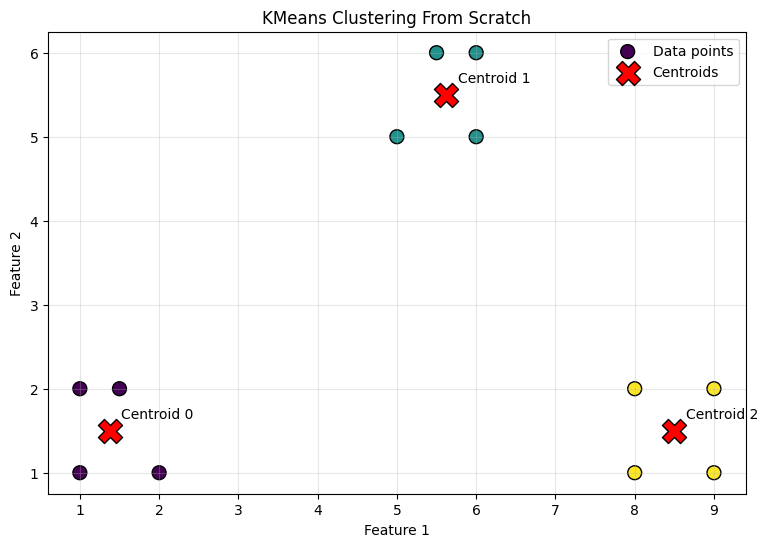

In [11]:
plt.figure(figsize=(9, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=kmeans.labels_,
    cmap="viridis",
    s=100,
    edgecolor="black",
    label="Data points"
)

plt.scatter(
    kmeans.centroids_[:, 0],
    kmeans.centroids_[:, 1],
    color="red",
    marker="X",
    s=300,
    edgecolor="black",
    label="Centroids"
)

for cluster_id, centroid in enumerate(
    kmeans.centroids_
):
    plt.text(
        centroid[0] + 0.15,
        centroid[1] + 0.15,
        f"Centroid {cluster_id}",
        fontsize=10
    )

plt.title("KMeans Clustering From Scratch")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [12]:
new_points = np.array([
    [1.2, 1.4],
    [5.8, 5.5],
    [8.7, 1.2]
])

predicted_clusters = kmeans.predict(
    new_points
)

for point, cluster in zip(
    new_points,
    predicted_clusters
):
    print(
        f"Point {point} belongs to "
        f"Cluster {cluster}"
    )

Point [1.2 1.4] belongs to Cluster 0
Point [5.8 5.5] belongs to Cluster 1
Point [8.7 1.2] belongs to Cluster 2


In [13]:
for iteration, centroids in enumerate(
    kmeans.centroid_history_
):
    print(f"Iteration {iteration}:")
    print(centroids)
    print()

Iteration 0:
[[1. 1.]
 [5. 5.]
 [8. 1.]]

Iteration 1:
[[1.375 1.5  ]
 [5.625 5.5  ]
 [8.5   1.5  ]]

Iteration 2:
[[1.375 1.5  ]
 [5.625 5.5  ]
 [8.5   1.5  ]]

